In [21]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("winequality-white.csv", sep=";")

In [22]:
# First 5 rows
df.head()

# Basic info: column types, missing values
df.info()

# Summary statistics for numeric features
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [5]:
df.isnull().sum()


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [18]:
import numpy as np

corr_matrix = df.corr().abs()
# Extract the upper triangle of the correlation matrix
# This avoids duplicate pairs and self-correlation
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
# Identify columns that have correlation >= 0.9 with any other column
# These indicate potential multicollinearity
high_corr_columns = [
    col for col in upper_triangle.columns
    if (upper_triangle[col] >= 0.9).any()
]

print(corr_matrix)
print(high_corr_columns)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.022697     0.289181   
volatile acidity           0.022697          1.000000     0.149472   
citric acid                0.289181          0.149472     1.000000   
residual sugar             0.089021          0.064286     0.094212   
chlorides                  0.023086          0.070512     0.114364   
free sulfur dioxide        0.049396          0.097012     0.094077   
total sulfur dioxide       0.091070          0.089261     0.121131   
density                    0.265331          0.027114     0.149503   
pH                         0.425858          0.031915     0.163748   
sulphates                  0.017143          0.035728     0.062331   
alcohol                    0.120881          0.067718     0.075729   
quality                    0.113663          0.194723     0.009209   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

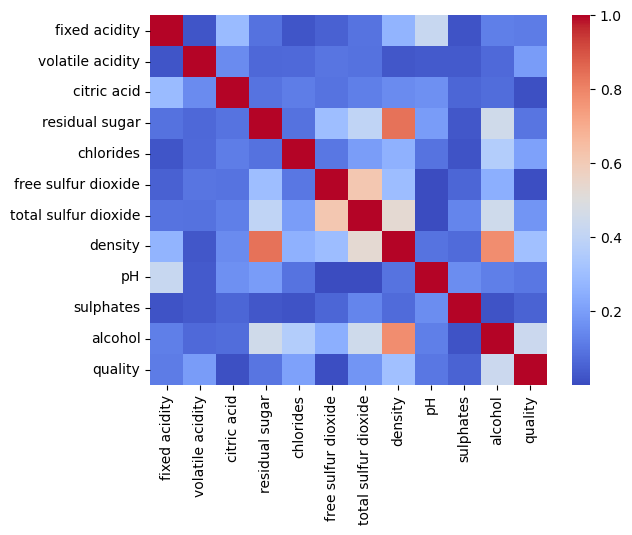

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.show()

# Result: No feature pairs exceed the 0.9 correlation threshold
# Interpretation: No severe multicollinearity detected

In [5]:
from sklearn.feature_selection import VarianceThreshold

def columns_low_variance(input_data, threshold=0.01):
    # Identify feature columns whose variance is below the given threshold
    # Low-variance features carry little information and may be removed
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(input_data)

    low_variance_columns = input_data.columns[~selector.get_support()]
    return list(low_variance_columns)


In [7]:
low_variance_columns = columns_low_variance(df, threshold=0.001)
print(list(low_variance_columns))


['chlorides', 'density']


In [4]:
import pandas as pd
range_df = pd.DataFrame({
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min()
})

print(range_df)


                          min        max      range
fixed acidity         3.80000   14.20000   10.40000
volatile acidity      0.08000    1.10000    1.02000
citric acid           0.00000    1.66000    1.66000
residual sugar        0.60000   65.80000   65.20000
chlorides             0.00900    0.34600    0.33700
free sulfur dioxide   2.00000  289.00000  287.00000
total sulfur dioxide  9.00000  440.00000  431.00000
density               0.98711    1.03898    0.05187
pH                    2.72000    3.82000    1.10000
sulphates             0.22000    1.08000    0.86000
alcohol               8.00000   14.20000    6.20000
quality               3.00000    9.00000    6.00000


In [20]:
# Features (all columns except target)
X = df.drop("quality", axis=1)

# Target
y = df["quality"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [22]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)

In [23]:
plt.figure(figsize=(22, 12))
plot_tree(
    model,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    max_depth=3,      # key line
    fontsize=8      # improves readability
)
plt.show()



NameError: name 'plot_tree' is not defined

<Figure size 2200x1200 with 0 Axes>

In [24]:
y_pred = model.predict(X_test)


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.5673338443416627
RMSE: 0.7332203154502249
R²: 0.30583514667605194


In [21]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, model.predict(X_train))
test_mae = mean_absolute_error(y_test, model.predict(X_test))

print(train_mae, test_mae)


0.5409303372691782 0.5673338443416627


The Decision Tree Regressor achieved an MAE of 0.57 and an RMSE of 0.73, indicating that predicted wine quality scores deviate on average by less than one point from the true values. The R² score of 0.31 reflects the inherent difficulty of predicting subjective wine quality using physicochemical properties alone.The training and test MAE values are very close (0.54 vs 0.57), indicating that the model generalizes well and does not suffer from overfitting.

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=200,
                          random_state=42)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_gb = gbr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae)
print("Gradient Boosting RMSE:", rmse)
print("Gradient Boosting R²:", r2)


Gradient Boosting MAE: 0.49767572884540967
Gradient Boosting RMSE: 0.6440437409696957
Gradient Boosting R²: 0.4644199767585765


In [30]:
train_mae = mean_absolute_error(y_train, gbr.predict(X_train))
test_mae = mean_absolute_error(y_test, y_pred_gb)

print(train_mae, test_mae)


0.39589208282606825 0.49767572884540967


In [ ]:
Compared to the Decision Tree Regressor, Gradient Boosting reduced the average prediction error by approximately 12%, highlighting the benefit of ensemble learning for modeling complex, non-linear relationships in wine quality data.While a Decision Tree Regressor learns a single set of threshold-based rules, Gradient Boosting optimizes model performance by sequentially minimizing prediction errors through successive modeling of residuals, resulting in improved predictive performance.

In [24]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
from pycaret.classification import *

# ===============================
# 2. Load dataset
# ===============================
df = pd.read_csv("winequality-white.csv", sep=";")  

# Check the actual column names in the dataset
print("Column names in the dataset:")
print(df.columns.tolist())
print(df.head())
print(df.shape)

# ===============================
# 3. Setup PyCaret
# ===============================

clf = setup(
    data=df,
    target='quality',  
    session_id=123,
    train_size=0.8,
    normalize=True
)

# ===============================
# 4. Compare selected models
# ===============================
best_model = compare_models(
    include=['lr','rf','et','gbc','ada'],
    fold=5
)

print("Best model:")
print(best_model)

# ===============================
# 5. Tune model
# ===============================
tuned_model = tune_model(best_model)

# ===============================
# 6. Evaluate model
# ===============================
evaluate_model(tuned_model)

# ===============================
# 7. Finalize model
# ===============================
final_model = finalize_model(tuned_model)

# ===============================
# 8. Predictions
# ===============================
predictions = predict_model(final_model)

print(predictions.head())

# ===============================
# 9. Save model
# ===============================
save_model(final_model,"quality")

Column names in the dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0 

,Description,Value
0,Session id,123
1,Target,quality
2,Target type,Multiclass
3,Target mapping,"3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6"
4,Original data shape,"(4898, 12)"
5,Transformed data shape,"(4898, 12)"
6,Transformed train set shape,"(3918, 12)"
7,Transformed test set shape,"(980, 12)"
8,Numeric features,11
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.6580,0.6778,0.6580,0.6635,0.6446,0.4642,0.4719,0.2960
rf,Random Forest Classifier,0.6539,0.6724,0.6539,0.6594,0.6398,0.4584,0.4657,0.3520
gbc,Gradient Boosting Classifier,0.5822,0.0000,0.5822,0.5791,0.5665,0.3444,0.3518,2.3420
lr,Logistic Regression,0.5299,0.0000,0.5299,0.5082,0.4905,0.2331,0.2476,0.9300
ada,Ada Boost Classifier,0.4390,0.0000,0.4390,0.3838,0.3578,0.0986,0.1168,0.1360


Best model:
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=123, verbose=0,
                     warm_start=False)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5561,0.0000,0.5561,0.5503,0.4969,0.2525,0.2890
1,0.5612,0.0000,0.5612,0.5616,0.5090,0.2694,0.2970
2,0.5408,0.0000,0.5408,0.5056,0.4902,0.2371,0.2615
3,0.5306,0.0000,0.5306,0.4829,0.4761,0.2174,0.2421
4,0.5255,0.7141,0.5255,0.4797,0.4719,0.2172,0.2362
5,0.5434,0.7377,0.5434,0.5121,0.4847,0.2440,0.2670
6,0.4923,0.6932,0.4923,0.4595,0.4324,0.1457,0.1671
7,0.5230,0.7009,0.5230,0.5465,0.4560,0.1934,0.2243
8,0.5320,0.0000,0.5320,0.5603,0.4687,0.2073,0.2405


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
3705            7.5             0.240         0.31            13.1      0.050   
4635            5.8             0.345         0.15            10.8      0.033   
712             8.2             0.270         0.43             1.6      0.035   
1546            6.7             0.290         0.49             4.7      0.034   
4584            5.9             0.340         0.25             2.0      0.042   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
3705                 26.0                 180.0  0.99884  3.05       0.53   
4635                 26.0                 120.0  0.99494  3.25       0.49   
712                  31.0                 128.0  0.99160  3.10       0.50   
1546                 35.0                 156.0  0.99450  3.13       0.45   
4584                 12.0                 110.0  0.99034  3.02       0.54   

      alcohol  quality  prediction_label  predicti

(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['fixed acidity',
                                              'volatile acidity', 'citric acid',
                                              'residual sugar', 'chlorides',
                                              'free sulfur dioxide',
                                              'total sulfur dioxide', 'density',
                                              'pH', 'sulphates...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                       class_weight=None, criterion='gini',
                                       max_depth=None, max_features='sqrt',
                    

The Extra Trees Classifier achieved the highest performance across most metrics (Accuracy, F1, Kappa, MCC), so it is selected as the best model for predicting wine quality.